# TME FORWARD MUSIC

* Songs without UPC will be excluded.
* Songs without ISCR will be granted synthetic ISCR, which is "Song - Artist".

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_SONGS_UNIQUE_ISRC,
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY,
    OUTPUT_ALL_REPORT_PATH,
    OUTPUT_CHART_PATH
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting
import os
import reporting

In [44]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/TME/ 
 ../output/FORWARD/TME_Song_Report_Forward.xlsx


In [45]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356630 entries, 240784 to 116318
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        356630 non-null  object 
 1   Platform         356630 non-null  object 
 2   Song             356630 non-null  object 
 3   ISRC             356630 non-null  object 
 4   Artist           356630 non-null  object 
 5   Album            350781 non-null  object 
 6   UPC              355121 non-null  object 
 7   Revenue          356630 non-null  float64
 8   Total_Clicks     356630 non-null  int64  
 9   source_file      356630 non-null  object 
 10  standard_song    356630 non-null  object 
 11  standard_artist  356630 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 35.4+ MB


In [46]:
# see where TW songs are
df_tw = df_cleaned[df_cleaned['ISRC'].str.startswith('TW', na=False)]
df_tw.groupby('source_file').agg('size')

source_file
aiting_song_outside_detail_CON02-TME00-20230731-0006_284097627_20240201-20240229-0530041126.xlsx      135
aiting_song_outside_detail_CON02-TME00-20230731-0006_329227508_20260501-20260531-0624014327.xlsx    10955
k_outside_detail_CON02-TME00-20230731-0006_329227508_20260501-20260531-0624073221.xlsx              18202
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_309273468_20250501-20250531-0621022436.xlsx       1661
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_329227508_20260501-20260531-0624021338.xlsx       1678
mv_outside_detail_ver_CON02-TME00-20230731-0006_kw_329227508_20260501-20260531-0624021318.xlsx          1
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_327765411_20260301-20260331-0522204557.xlsx       1193
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_329227508_20260501-20260531-0624021348.xlsx       1225
single_outside_detail_CON02-TME00-20230731-0006_kg_329227508_20260501-20260531-0624020709.xlsx       1242
single_outside_detail_CON02-TME00-

In [47]:
# Exclude Taiwan songs (ISRC starting with 'TW') and drop empty ISRC
df_cleaned = df_cleaned[~df_cleaned['ISRC'].str.startswith('TW', na=False)]

In [48]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298797 entries, 240784 to 126702
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   YearMonth        298797 non-null  object 
 1   Platform         298797 non-null  object 
 2   Song             298797 non-null  object 
 3   ISRC             298797 non-null  object 
 4   Artist           298797 non-null  object 
 5   Album            298706 non-null  object 
 6   UPC              297567 non-null  object 
 7   Revenue          298797 non-null  float64
 8   Total_Clicks     298797 non-null  int64  
 9   source_file      298797 non-null  object 
 10  standard_song    298797 non-null  object 
 11  standard_artist  298797 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 29.6+ MB


## Investigate NA data

In [49]:
# calculate NA
is_missing = df_cleaned.isna() | (df_cleaned == '') | df_cleaned.astype(str).apply(lambda s: s.str.lower() == 'nan')

missing_summary = pd.DataFrame({
    '缺失值總計 (含空字串/\'nan\')': is_missing.sum(),
    '缺失值比例 (%)': (is_missing.mean() * 100).round(2)
})

print("\n--- 完整缺失值統計 (含空字串與 'nan' 字串) ---")
display(missing_summary.sort_values(by='缺失值總計 (含空字串/\'nan\')', ascending=False))


--- 完整缺失值統計 (含空字串與 'nan' 字串) ---


,缺失值總計 (含空字串/'nan'),缺失值比例 (%)
UPC,1230,0.41
Album,91,0.03
YearMonth,0,0.00
Platform,0,0.00
Song,0,0.00
ISRC,0,0.00
Artist,0,0.00
Revenue,0,0.00
Total_Clicks,0,0.00
source_file,0,0.00


In [50]:
df_cleaned.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
240784,2024-01,Kugou,正义柔情永在,HKG631891029,"陈松伶,温兆伦",仙侣奇缘•忠奸老实人,UPC-4715202900794,0.588000,1,single_outside_detail_CON02-TME00-20230731-000...,正义柔情永在,"温兆伦, 陈松伶"
234337,2024-01,Kugou,江湖浪子,HKG631884085,麦洁文,江湖浪子,UPC-4715202900688,35.352611,9473,song_outside_detail_CON02-TME00-20230731-0006_...,江湖浪子,麦洁文
234336,2024-01,Kugou,飞鹰,HKG631881061,郑少秋,飞鹰,UPC-4715202901739,1.537738,1409,song_outside_detail_CON02-TME00-20230731-0006_...,飞鹰,郑少秋
234335,2024-01,Kugou,何时再登岸,HKG631881066,郑少秋,飞鹰,UPC-4715202901739,0.141761,84,song_outside_detail_CON02-TME00-20230731-0006_...,何时再登岸,郑少秋
234334,2024-01,Kugou,令我心温暖,HKG631881067,郑少秋,飞鹰,UPC-4715202901739,0.014432,21,song_outside_detail_CON02-TME00-20230731-0006_...,令我心温暖,郑少秋


In [51]:
missing_upc = df_cleaned[df_cleaned['UPC'].isna()]
missing_upc.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
313001,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.000739,1,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩
313002,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.001479,2,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩
313003,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.001479,2,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩
313004,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.000000,0,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩
313005,2025-05,Kugou,思念你,思念你 - ZEN俊倩,Zen 俊倩,NaN,NaN,0.000000,0,mv_outside_detail_ver_CON02-TME00-20230731-000...,思念你,Zen 俊倩


In [52]:
# identify NA data in source file
df_cleaned[df_cleaned['UPC'].isna()].groupby('source_file').size()


source_file
aiting_song_outside_detail_CON02-TME00-20230731-0006_329227508_20260501-20260531-0624014327.xlsx    149
k_outside_detail_CON02-TME00-20230731-0006_329227508_20260501-20260531-0624073221.xlsx              513
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_309273468_20250501-20250531-0621022436.xlsx       11
mv_outside_detail_ver_CON02-TME00-20230731-0006_kg_329227508_20260501-20260531-0624021338.xlsx       47
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_327765411_20260301-20260331-0522204557.xlsx       11
mv_outside_detail_ver_CON02-TME00-20230731-0006_qq_329227508_20260501-20260531-0624021348.xlsx       22
song_outside_detail_CON02-TME00-20230731-0006_kg_329227508_20260501-20260531-0624012515.xlsx        159
song_outside_detail_CON02-TME00-20230731-0006_kw_329227508_20260501-20260531-0624013254.xlsx        159
song_outside_detail_CON02-TME00-20230731-0006_qq_329227508_20260501-20260531-0624005239.xlsx        159
dtype: int64

## Check song and artist name discrepancy

In [53]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Song'].unique()
result = temp[temp.apply(len) > 1]
song_mismatch = pd.DataFrame(result).reset_index()
song_mismatch

,ISRC,UPC,Song
0,HKG631877015,UPC-4715202900497,"[乘风破浪主题曲音乐(二), 乘风破浪主题曲音乐 (二)]"
1,HKG631877016,UPC-4715202900497,"[狂潮主题曲音乐(二), 狂潮主题曲音乐 (二)]"
2,HKG631877018,UPC-4715202900497,"[心有千千结主题曲音乐(二), 心有千千结主题曲音乐 (二)]"
3,HKG631883001,UPC-4715202900923,"[我祇有期待, 我只有期待]"
4,HKG631883008,UPC-4715202900923,"[祇对着一个影, 只对着一个影]"
5,HKG631896030,UPC-4715202900985,"[男儿着眼天地开, 男儿着眼天地间]"


In [54]:
temp = df_cleaned.groupby(['ISRC', 'UPC'])['Artist'].unique()
result = temp[temp.apply(len) > 1]
artist_mismatch = pd.DataFrame(result).reset_index()
artist_mismatch

,ISRC,UPC,Artist
0,HKG631862002,UPC-4715202901333,"[梁醒波,朱少坡, 朱少坡,梁醒波]"


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,clicks,Click_MoM_Growth,revenue,Rev_MoM_Growth
0,2024-01,41898461,N/A,209852.907614,N/A
1,2024-02,30164684,-28.01%,181187.764300,-13.66%
2,2024-03,34689601,15.00%,172953.388391,-4.54%
3,2024-04,33077193,-4.65%,156990.340699,-9.23%
4,2024-05,33142087,0.20%,158068.380902,0.69%
5,2024-06,30624298,-7.60%,152164.607659,-3.73%
6,2024-07,31095075,1.54%,140728.021413,-7.52%
7,2024-08,31079126,-0.05%,141927.807687,0.85%
8,2024-09,30021739,-3.40%,141598.080387,-0.23%
9,2024-10,31267332,4.15%,141383.415110,-0.15%


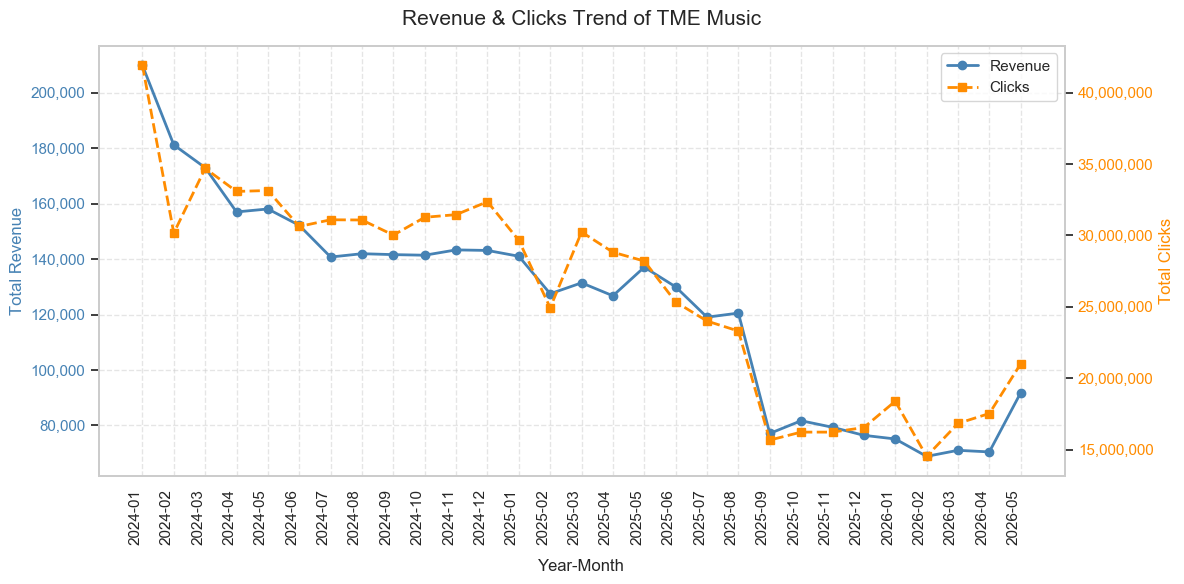

In [55]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['Rev_MoM_Growth'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

revenue_by_month['Click_MoM_Growth'] = (
    revenue_by_month['clicks']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

new_order = ['YearMonth', 'clicks', 'Click_MoM_Growth', 'revenue','Rev_MoM_Growth']
revenue_by_month = revenue_by_month[new_order]
print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph and Save to folder
chart_filename = "TME_Revenue_Clicks_Trend.png"
save_file_path = os.path.join(OUTPUT_CHART_PATH, chart_filename)

plotting.plot_revenue_clicks_trend(revenue_by_month, save_path=save_file_path)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [56]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 298797 rows.


## Top Songs Share (dup ISRC)

In [101]:
df_filtered.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
240784,2024-01,Kugou,正义柔情永在,HKG631891029,"陈松伶,温兆伦",仙侣奇缘•忠奸老实人,UPC-4715202900794,0.588000,1,single_outside_detail_CON02-TME00-20230731-000...,正义柔情永在,"温兆伦, 陈松伶"
234337,2024-01,Kugou,江湖浪子,HKG631884085,麦洁文,江湖浪子,UPC-4715202900688,35.352611,9473,song_outside_detail_CON02-TME00-20230731-0006_...,江湖浪子,麦洁文
234336,2024-01,Kugou,飞鹰,HKG631881061,郑少秋,飞鹰,UPC-4715202901739,1.537738,1409,song_outside_detail_CON02-TME00-20230731-0006_...,飞鹰,郑少秋
234335,2024-01,Kugou,何时再登岸,HKG631881066,郑少秋,飞鹰,UPC-4715202901739,0.141761,84,song_outside_detail_CON02-TME00-20230731-0006_...,何时再登岸,郑少秋
234334,2024-01,Kugou,令我心温暖,HKG631881067,郑少秋,飞鹰,UPC-4715202901739,0.014432,21,song_outside_detail_CON02-TME00-20230731-0006_...,令我心温暖,郑少秋


In [102]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        album=('Album', 'first'),
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

In [103]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['revenue_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)

pie_chart_filename = "Song_Contribution_Pie.png"
save_pie_path = os.path.join(OUTPUT_CHART_PATH, pie_chart_filename)
# plotting.plot_pie_charts(df_pie, save_path=save_pie_path)

Top 10 songs contribute to 74.68% of total revenue.


,UPC,ISRC,album,song,artist,revenue,clicks,revenue_share,click_share
687,UPC-4715202900930,HKG631895001,笑看风云,笑看风云,郑少秋,1.121975e+06,222093663,0.310953,0.292845
528,UPC-4715202900800,HKG631892001,我是情痴·随缘,随缘,温兆伦,4.324147e+05,70158361,0.119843,0.092508
632,UPC-4715202900909,HKG631892001,投入生命,随缘,温兆伦,4.178725e+05,77258441,0.115813,0.101870
336,UPC-4715202900633,HKG631882039,万水千山总是情 电视剧原声带,万水千山总是情,汪明荃,2.002313e+05,51551289,0.055494,0.067974
377,UPC-4715202900671,HKG631882039,金曲精选,万水千山总是情,汪明荃,1.364007e+05,41736040,0.037803,0.055032
609,UPC-4715202900879,HKG631893007,大时代,摘下满天星,郑少秋,1.324586e+05,23693496,0.036711,0.031241
641,UPC-4715202900916,HKG631894001,天边洒的不是雨,缘份,陈松伶,6.740600e+04,15498853,0.018681,0.020436
1044,UPC-4715202901241,HKG631895019,国语最佳精选辑,天地情缘,温兆伦,6.407043e+04,14545100,0.017757,0.019179
754,UPC-4715202900985,HKG631896029,天地男儿,从不放弃,郑少秋,6.286054e+04,9741518,0.017422,0.012845
968,UPC-4715202901173,HKG631878001,小李飞刀,小李飞刀,罗文,5.887787e+04,10385895,0.016318,0.013694


## Top Songs Share (unique ISRC)

In [127]:
# unique ISRC, exclude duplicate UPC
revenue_by_song_unique_ISRC = (
    revenue_by_song
    .groupby('ISRC')
    .agg(
        # album=('album', 'first'),
        song=('song', 'first'),
        artist=('artist', 'first'),
        revenue=('revenue', 'sum'),
        clicks=('clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song_unique_ISRC = revenue_by_song_unique_ISRC.sort_values('revenue', ascending=False)


Top 10 songs contribute to 78.26% of total revenue.


,ISRC,song,artist,revenue,clicks,revenue_share,click_share
763,HKG631895001,笑看风云,郑少秋,1.121975e+06,222093663,0.310953,0.292845
643,HKG631892001,随缘,温兆伦,8.502872e+05,147416802,0.235656,0.194379
432,HKG631882039,万水千山总是情,汪明荃,3.631877e+05,96437006,0.100657,0.127159
693,HKG631893007,摘下满天星,郑少秋,1.324586e+05,23693496,0.036711,0.031241
726,HKG631894001,缘份,陈松伶,6.740600e+04,15498853,0.018681,0.020436
194,HKG631878001,小李飞刀,罗文,6.484825e+04,11799307,0.017973,0.015558
777,HKG631895019,天地情缘,温兆伦,6.407043e+04,14545100,0.017757,0.019179
853,HKG631896029,从不放弃,郑少秋,6.286054e+04,9741518,0.017422,0.012845
634,HKG631891029,正义柔情永在,"温兆伦, 陈松伶",4.850188e+04,10014813,0.013442,0.013205
622,HKG631891016,从未试过拥有,温兆伦,4.822033e+04,12809672,0.013364,0.016890


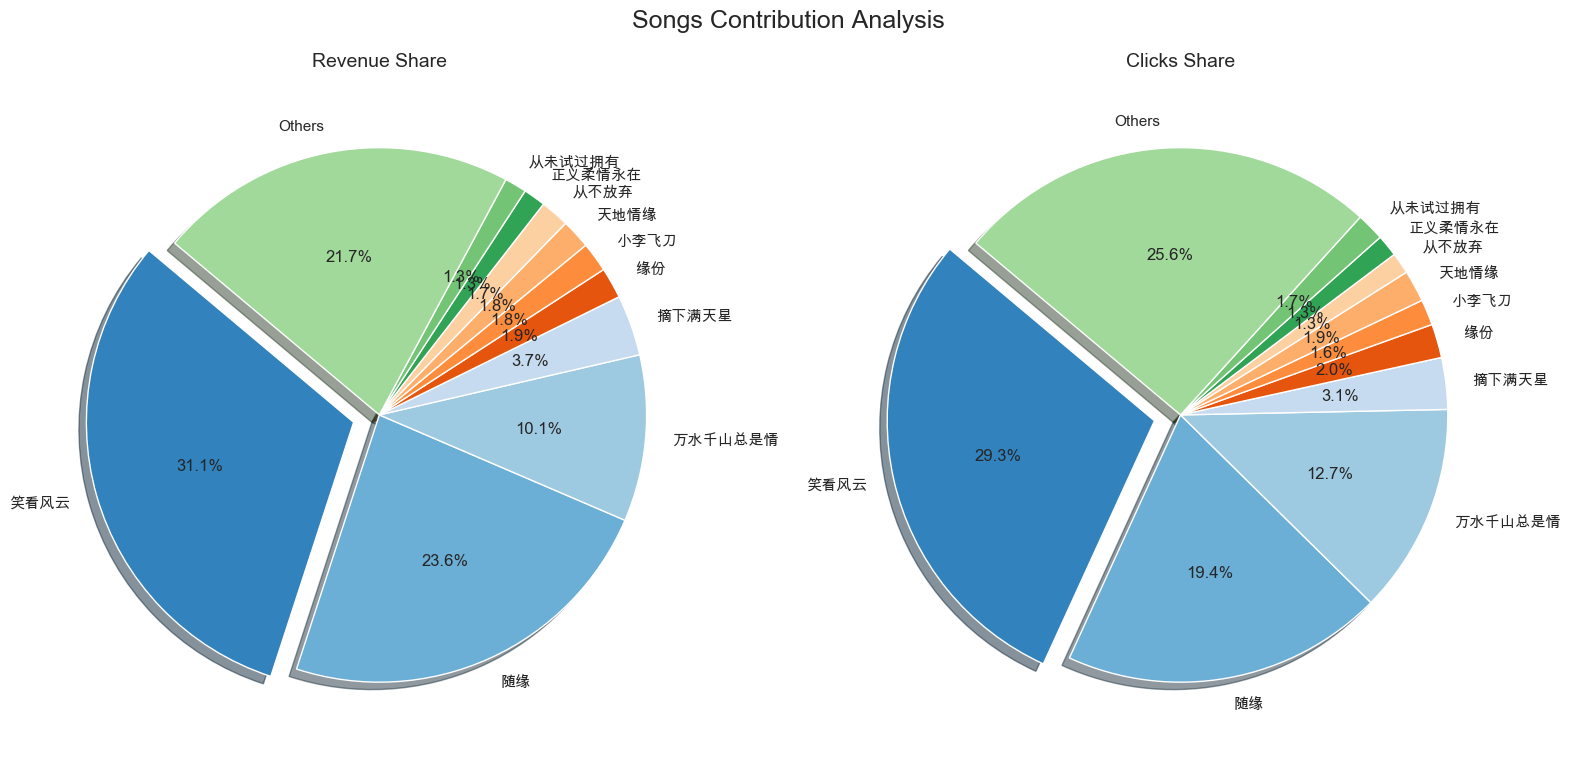

Top 30 songs contribute to 89.68% of total revenue.


,ISRC,song,artist,revenue,clicks,revenue_share,click_share
763,HKG631895001,笑看风云,郑少秋,1.121975e+06,222093663,0.310953,0.292845
643,HKG631892001,随缘,温兆伦,8.502872e+05,147416802,0.235656,0.194379
432,HKG631882039,万水千山总是情,汪明荃,3.631877e+05,96437006,0.100657,0.127159
693,HKG631893007,摘下满天星,郑少秋,1.324586e+05,23693496,0.036711,0.031241
726,HKG631894001,缘份,陈松伶,6.740600e+04,15498853,0.018681,0.020436
194,HKG631878001,小李飞刀,罗文,6.484825e+04,11799307,0.017973,0.015558
777,HKG631895019,天地情缘,温兆伦,6.407043e+04,14545100,0.017757,0.019179
853,HKG631896029,从不放弃,郑少秋,6.286054e+04,9741518,0.017422,0.012845
634,HKG631891029,正义柔情永在,"温兆伦, 陈松伶",4.850188e+04,10014813,0.013442,0.013205
622,HKG631891016,从未试过拥有,温兆伦,4.822033e+04,12809672,0.013364,0.016890


In [128]:
# plot pie chart
total_rev = revenue_by_song_unique_ISRC['revenue'].sum()
total_clicks = revenue_by_song_unique_ISRC['clicks'].sum()

revenue_by_song_top_unique_ISRC = revenue_by_song_unique_ISRC.head(TOP_N_SONGS).copy()
revenue_by_song_top_unique_ISRC['revenue_share'] = revenue_by_song_top_unique_ISRC['revenue'] / total_rev
revenue_by_song_top_unique_ISRC['click_share'] = revenue_by_song_top_unique_ISRC['clicks'] / total_clicks
top_song_list = revenue_by_song_top_unique_ISRC['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top_unique_ISRC['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top_unique_ISRC)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song_unique_ISRC.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song_unique_ISRC[~revenue_by_song_unique_ISRC['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song_unique_ISRC[~revenue_by_song_unique_ISRC['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)

pie_chart_filename = "Song_Contribution_Pie_Unique_ISRC.png"
save_pie_path = os.path.join(OUTPUT_CHART_PATH, pie_chart_filename)
plotting.plot_pie_charts(df_pie, save_path=save_pie_path)

# generate top N report
revenue_by_song_topN_unique_ISRC = revenue_by_song_unique_ISRC.head(TOP_N_SONGS_UNIQUE_ISRC).copy()
revenue_by_song_topN_unique_ISRC['revenue_share'] = revenue_by_song_topN_unique_ISRC['revenue'] / total_rev
revenue_by_song_topN_unique_ISRC['click_share'] = revenue_by_song_topN_unique_ISRC['clicks'] / total_clicks
top30_song_list = revenue_by_song_topN_unique_ISRC['ISRC'].tolist()

print(f"Top {TOP_N_SONGS_UNIQUE_ISRC} songs contribute to {revenue_by_song_topN_unique_ISRC['revenue_share'].sum():.2%} of total revenue.")
display(revenue_by_song_topN_unique_ISRC)


## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [129]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)
song_final.head()

Song report exported successfully to: ../output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx


,ISRC,song,artist,UPC,album,total_click,total_revenue,2024-01_clicks,2024-01_revenue,2024-02_clicks,...,2026-01_clicks,2026-01_revenue,2026-02_clicks,2026-02_revenue,2026-03_clicks,2026-03_revenue,2026-04_clicks,2026-04_revenue,2026-05_clicks,2026-05_revenue
0,HKG631895001,笑看风云,郑少秋,UPC-4715202900930,笑看风云,222093663,1.121975e+06,12551280,66241.968418,9789967,...,2390068,5328.494253,1781473,3760.102854,1903305,3251.710876,3009001,6597.125502,6363348,23099.617103
1,HKG631892001,随缘,温兆伦,UPC-4715202900800,我是情痴·随缘,70158361,4.324147e+05,7333158,47152.967315,4029332,...,1811273,9320.687824,1572396,9382.119456,1693831,8760.517125,1715161,8498.565327,1660718,9018.841613
2,HKG631892001,随缘,温兆伦,UPC-4715202900909,投入生命,77258441,4.178725e+05,6050976,31024.625351,3382755,...,2404375,10381.962677,1873381,9836.923195,2323522,10108.575414,2332945,9913.993457,2174204,10128.234933
3,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900633,万水千山总是情 电视剧原声带,51551289,2.002313e+05,2161371,7674.824207,2048345,...,1044828,5159.672531,870320,4985.058082,955162,4842.801410,962915,4601.108473,963272,4631.924877
4,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900671,金曲精选,41736040,1.364007e+05,1661393,5215.694363,1431046,...,1026187,3756.540136,823857,3365.033480,945043,3454.489675,903543,3351.519916,913797,3510.024223


## Monthly Revenue Trend for Top Songs

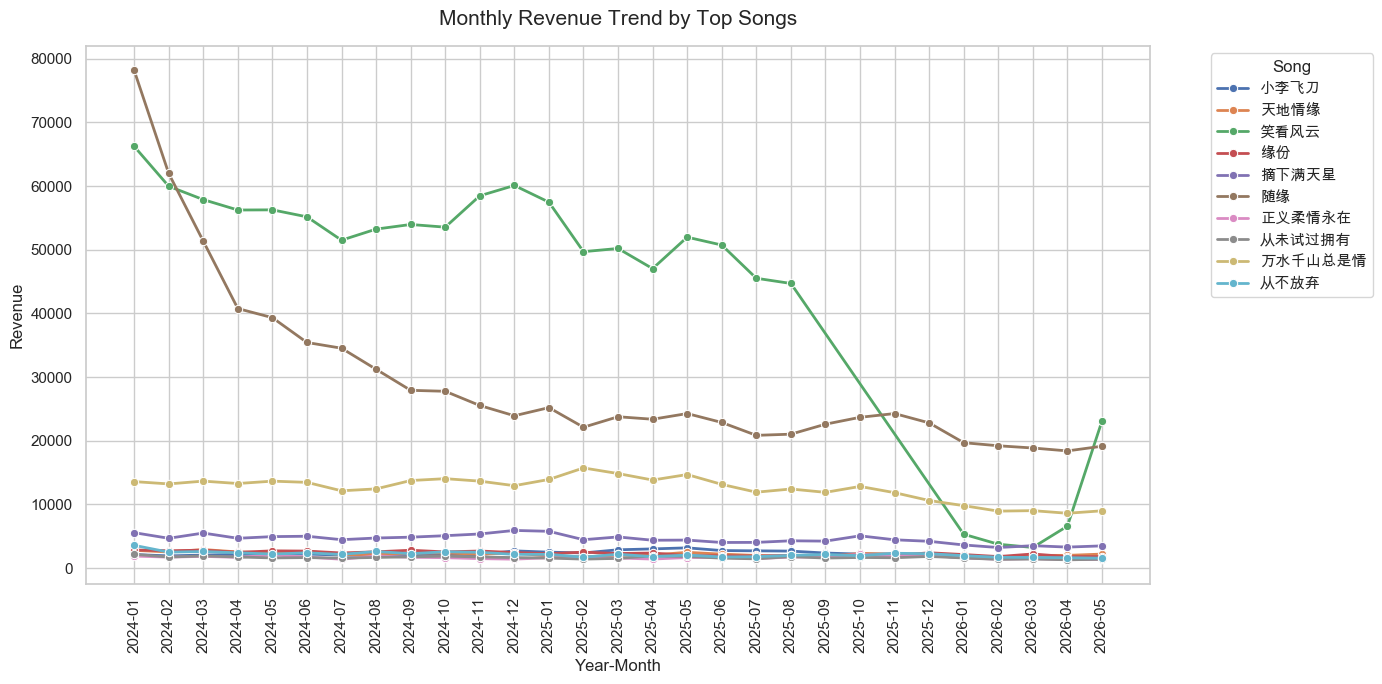

In [130]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[revenue_by_song_per_month['ISRC'].isin(top_song_list)].sort_values('YearMonth')

song_trend_path = os.path.join(OUTPUT_CHART_PATH, "Monthly_Revenue_by_Top_Songs.png")
plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS, save_path=song_trend_path)

## Revenue by Platform

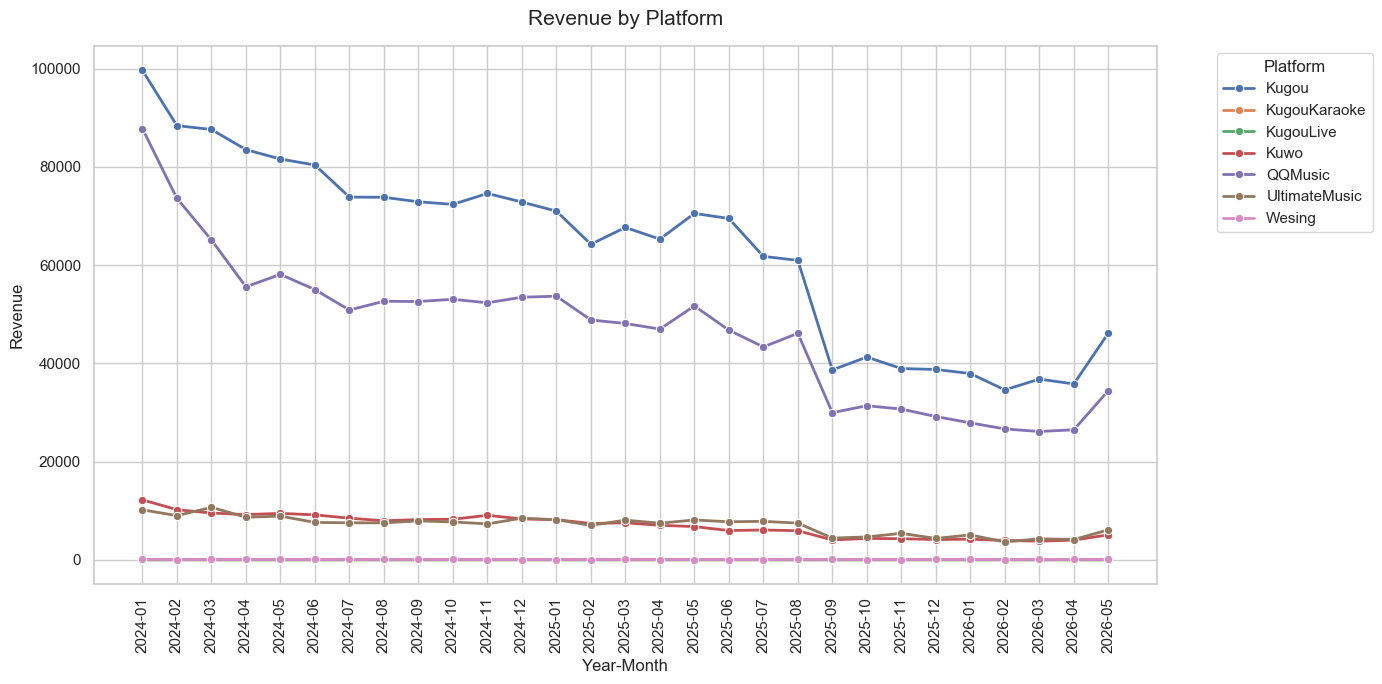

In [131]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

platform_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Platform.png")
plotting.plot_revenue_by_platform(revenue_by_platform, save_path=platform_trend_path)

## Generate Album Report & Plot Revenue by Album

In [132]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]

album_trend_path = os.path.join(OUTPUT_CHART_PATH, "Revenue_by_Album.png")
# plotting.plot_revenue_by_album(top_album_trend, save_path=album_trend_path)

Top 10 albums contribute to 81.48% of total revenue.


## Find Missing ISRC Song

In [133]:
df_with_dash = song_final[song_final['ISRC'].str.contains('-')]
df_with_dash = df_with_dash[['ISRC', 'song', 'artist', 'UPC', 'album']]
df_with_dash

,ISRC,song,artist,UPC,album
117,声声慢 - 邓福如AFÜ,声声慢,邓福如 AFÜ,UPC-4715202207206,原来如此
699,我和你 - 仙杜拉,我和你,仙杜拉,UPC-4715202900473,啼笑因缘
1078,细语 - 蔡琴,细语,蔡琴,UPC-196873303956,情是什么
1079,小夜曲 - 蔡琴,小夜曲,蔡琴,UPC-4711280029006,昨夜之灯
1097,刘姥姥进大观园 - 陈思玮,刘姥姥进大观园,陈思玮,UPC-4715202209415,你 这家伙
1124,你这家伙 - 陈思玮,你 这家伙,陈思玮,UPC-4715202209415,你 这家伙
1128,小宝贝 - 陈思玮,小宝贝,陈思玮,UPC-4715202209415,你 这家伙
1133,HEARITAGESONG - 纪懿珍,Hearitage Song,纪懿珍,UPC-4715202300686,十二生肖贺新年
1141,中华新年颂(CHINESEVERSION) - 纪懿珍,中华新年颂(Chinese Version),纪懿珍,UPC-4715202300686,十二生肖贺新年
1177,爱情汤味 - 陈思玮,爱情汤味,陈思玮,UPC-4715202209415,你 这家伙


## Generate in one Excel file

In [134]:
sheets_dict = {
    'Monthly_Rev_Click': song_final,
    'Total_Revenue': revenue_by_month,
    'Top_30': revenue_by_song_topN_unique_ISRC,
    'Missing_ISRC': df_with_dash,
    'Missing_UPC': missing_upc,
    # 'Song_mismatch': song_mismatch,
    # 'Artist_mismatch': artist_mismatch,
}

with pd.ExcelWriter(OUTPUT_ALL_REPORT_PATH, engine='openpyxl') as writer:
    for sheet_name, df in sheets_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

reporting.style_excel_file(OUTPUT_ALL_REPORT_PATH)

## Compare Two Files

In [135]:
FILE1_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_Monthly_Forward.xlsx"
FILE2_PATH = "/Users/chu-chun/Mirror/Eva/output/FORWARD/TME_Song_Report_202401_202603_舊版.xlsx"

df1 = pd.read_excel(FILE1_PATH)
df2 = pd.read_excel(FILE2_PATH)

# 合併 col1 + col2 形成比較用 key
df1["key"] = df1["ISRC"].astype(str) + "_" + df1["UPC"].astype(str)
df2["key"] = df2["ISRC"].astype(str) + "_" + df2["song"].astype(str)

result = df1[["key"]].merge(
    df2[["key"]],
    on="key",
    how="outer",
    indicator=True
)

print(result["_merge"].value_counts())

only_in_file1 = result[result["_merge"] == "left_only"]
only_in_file2 = result[result["_merge"] == "right_only"]

_merge
both          1078
left_only      143
right_only       0
Name: count, dtype: int64


In [136]:
print(df1["key"].duplicated().sum())
print(df2["key"].duplicated().sum())

3
0


In [137]:
print("df1 rows =", len(df1))
print("df1 unique =", df1["key"].nunique())

print("df2 rows =", len(df2))
print("df2 unique =", df2["key"].nunique())

df1 rows = 1221
df1 unique = 1218
df2 rows = 1075
df2 unique = 1075


In [138]:
dup_keys = df1.loc[df1["key"].duplicated(keep=False), "key"]
print(dup_keys.unique())

['HKG631877015_UPC-4715202900497' 'HKG631877016_UPC-4715202900497'
 'HKG631877018_UPC-4715202900497']
